## Simulated Annealing

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import ipywidgets as widgets
from ipywidgets import VBox, HBox, Layout
from IPython.display import display, clear_output
from scipy.spatial.distance import pdist
import random

In [87]:
def simulated_annealing(df, initial_temp=1000, final_temp=1, alpha=0.95, max_iter=1000, num_points=20, is_random=True, return_history=False):
    df = df.copy()

    def fitness_function(point_indices):
        points = df.loc[point_indices]
        suitability_score = points['avg_score'].sum()

        penalty = 0
        lat_array = points['lat'].values
        lon_array = points['lon'].values

        for i in range(len(points)):
            for j in range(i + 1, len(points)):
                lat_diff_km = abs(lat_array[i] - lat_array[j]) * 111
                lon_diff_km = abs(lon_array[i] - lon_array[j]) * 86.25
                distance_km = np.sqrt(lat_diff_km**2 + lon_diff_km**2)
                if distance_km < 100:
                    penalty += 1 / (distance_km + 1e-6)

        lambda_penalty = 10
        return suitability_score - lambda_penalty * penalty

    if is_random:
        current_solution = list(np.random.choice(df.index, num_points, replace=False))
    else:
        current_solution = list(df.sort_values("avg_score", ascending=False).head(num_points).index)

    current_score = fitness_function(current_solution)
    best_solution = current_solution[:]
    best_score = current_score

    fitness_history = [current_score]

    temperature = initial_temp
    iteration = 0

    while temperature > final_temp and iteration < max_iter:
        new_solution = current_solution[:]
        idx_to_replace = random.randint(0, num_points - 1)
        removed_index = current_solution[idx_to_replace]
        removed_point = df.loc[removed_index]

        remaining_indices = [i for i in df.index if i not in current_solution]
        remaining_df = df.loc[remaining_indices]

        if temperature > initial_temp * 0.5:
            new_point = random.choice(remaining_indices)
        else:
            remaining_df["distance"] = np.sqrt(
                ((remaining_df["lat"] - removed_point["lat"]) * 111) ** 2 +
                ((remaining_df["lon"] - removed_point["lon"]) * 86.25) ** 2
            )
            new_point = remaining_df.sort_values("distance").index[0]

        new_solution[idx_to_replace] = new_point
        new_score = fitness_function(new_solution)
        delta = new_score - current_score

        if delta > 0 or random.random() < np.exp(delta / temperature):
            current_solution = new_solution
            current_score = new_score
            if new_score > best_score:
                best_solution = new_solution
                best_score = new_score

        fitness_history.append(current_score)
        temperature *= alpha
        iteration += 1

    best_points_df = df.loc[best_solution]
    filename = "best_20_points_sa_random.csv" if is_random else "best_20_points_sa_guided.csv"
    best_points_df.to_csv(filename, index=False)

    if return_history:
        return best_solution, best_score, fitness_history
    else:
        return best_solution, best_score


In [114]:
df = pd.read_csv("../lat_lon_avg_score.csv")

# 1. Top-20 Direct
top_20_points = df.nlargest(20, 'avg_score')

# 2. Simulated Annealing - Random
random_solution_indices, _ = simulated_annealing(df, is_random=True)
random_solution = df.loc[random_solution_indices]

# 3. Simulated Annealing - Top-20
guided_solution_indices, _ = simulated_annealing(df, is_random=False)
guided_solution = df.loc[guided_solution_indices]

def evaluate_point_set(df_subset):
    coords = df_subset[['lat', 'lon']].values
    distances = pdist(coords)
    mean_distance = np.mean(distances)
    mean_score = df_subset['avg_score'].mean()
    return mean_distance, mean_score

top20_dist, top20_score = evaluate_point_set(top_20_points)
random_dist, random_score = evaluate_point_set(random_solution)
guided_dist, guided_score = evaluate_point_set(guided_solution)

comparison_df = pd.DataFrame({
    'Method': ['Top-20 Direct', 'SA (Random Start)', 'SA (Top-20 Start)'],
    'Mean Distance Between Points': [top20_dist, random_dist, guided_dist],
    'Mean Suitability Score': [top20_score, random_score, guided_score]
})

print(comparison_df)


              Method  Mean Distance Between Points  Mean Suitability Score
0      Top-20 Direct                      4.308333                0.785067
1  SA (Random Start)                      6.928796                0.551719
2  SA (Top-20 Start)                      5.762465                0.602489


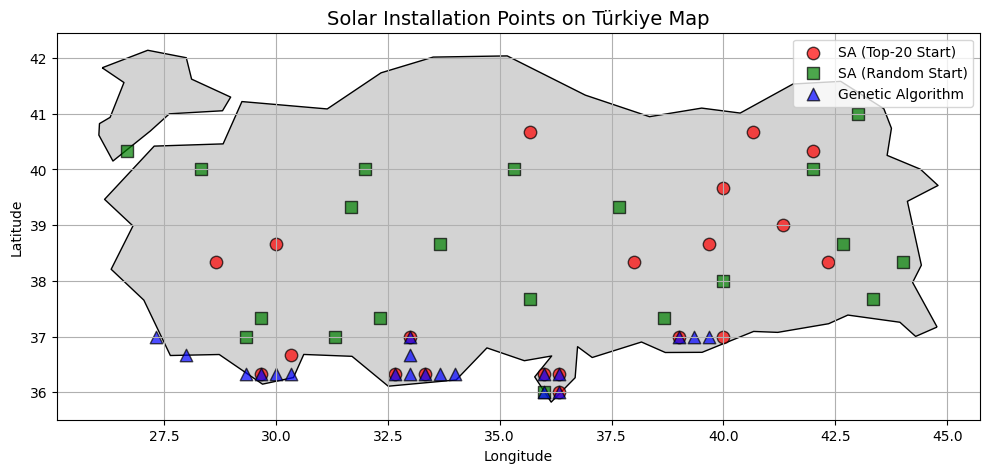

In [115]:
world = gpd.read_file("ne_110m_admin_0_countries.shp")
turkey = world[world["ADMIN"] == "Turkey"]

top20_points = pd.read_csv('top_20_points_direct.csv')
sa_random = pd.read_csv('best_20_points_sa_random.csv')
sa_guided = pd.read_csv('best_20_points_sa_guided.csv')

gdf_ga = gpd.GeoDataFrame(
    top20_points,
    geometry=gpd.points_from_xy(top20_points.lon, top20_points.lat),
    crs="EPSG:4326"
)

gdf_random = gpd.GeoDataFrame(
    sa_random,
    geometry=gpd.points_from_xy(sa_random.lon, sa_random.lat),
    crs="EPSG:4326"
)

gdf_guided = gpd.GeoDataFrame(
    sa_guided,
    geometry=gpd.points_from_xy(sa_guided.lon, sa_guided.lat),
    crs="EPSG:4326"
)

# Plot
fig, ax = plt.subplots(figsize=(10, 12))
turkey.plot(ax=ax, color='lightgray', edgecolor='black')

# Plot all three sets
gdf_guided.plot(ax=ax, color='red', marker='o', markersize=80, label='SA (Top-20 Start)', edgecolor='black', alpha=0.7)
gdf_random.plot(ax=ax, color='green', marker='s', markersize=80, label='SA (Random Start)', edgecolor='black', alpha=0.7)
gdf_ga.plot(ax=ax, color='blue', marker='^', markersize=80, label='Genetic Algorithm', edgecolor='black', alpha=0.7)

plt.title("Solar Installation Points on Türkiye Map", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## SA Random Experiments

In [125]:
initial_temps = [500, 1000, 1500, 2000]
alphas = [0.90, 0.95, 0.98]
final_temps = [10, 1, 0.1, 0.01]

df_input = pd.read_csv("../lat_lon_avg_score.csv")

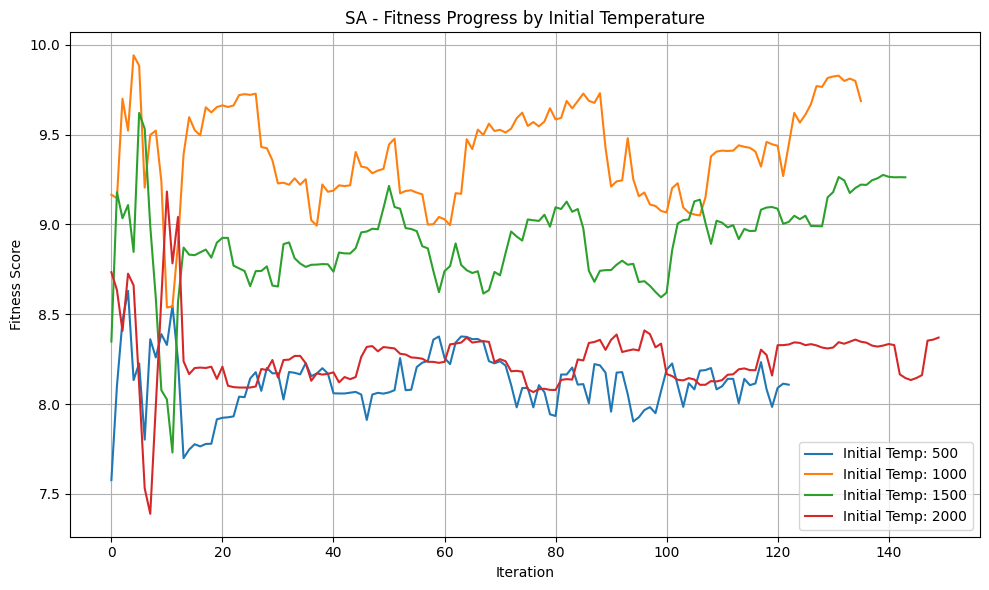

In [121]:
fitness_histories = []

for temp in initial_temps:
    _, _, history = simulated_annealing(
        df=df_input.copy(),
        initial_temp=temp,
        final_temp=1,
        alpha=0.95,
        max_iter=500,
        num_points=20,
        is_random=True,
        return_history=True
    )
    fitness_histories.append((temp, history))

# Plot
plt.figure(figsize=(10, 6))
for temp, history in fitness_histories:
    plt.plot(history, label=f'Initial Temp: {temp}')
plt.title("SA - Fitness Progress by Initial Temperature")
plt.xlabel("Iteration")
plt.ylabel("Fitness Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


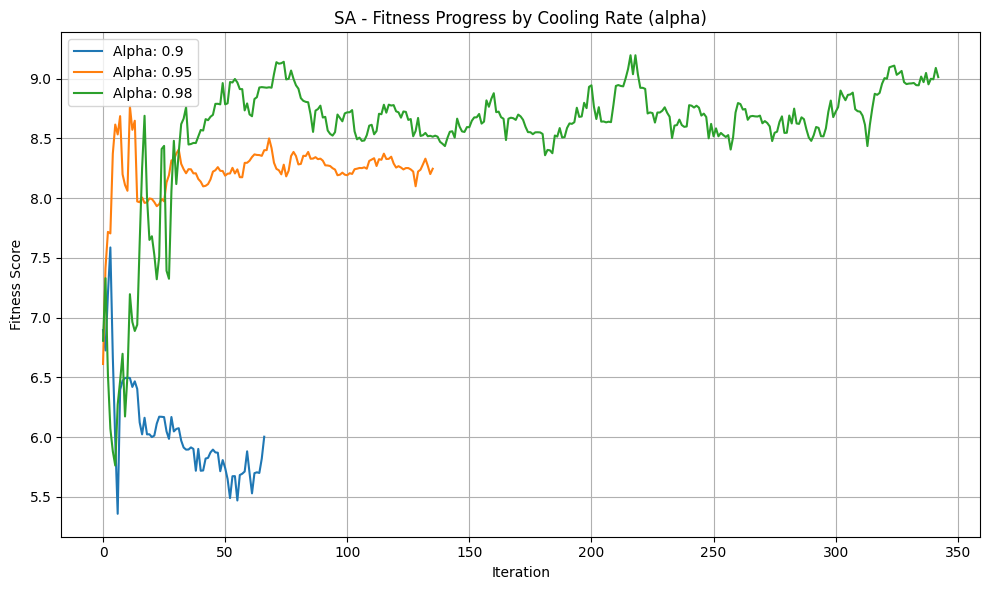

In [122]:
fitness_histories_alpha = []

for alpha in alphas:
    _, _, history = simulated_annealing(
        df=df_input.copy(),
        initial_temp=1000,
        final_temp=1,
        alpha=alpha,
        max_iter=500,
        num_points=20,
        is_random=True,
        return_history=True
    )
    fitness_histories_alpha.append((alpha, history))

# Plot
plt.figure(figsize=(10, 6))
for alpha, history in fitness_histories_alpha:
    plt.plot(history, label=f'Alpha: {alpha}')
plt.title("SA - Fitness Progress by Cooling Rate (alpha)")
plt.xlabel("Iteration")
plt.ylabel("Fitness Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


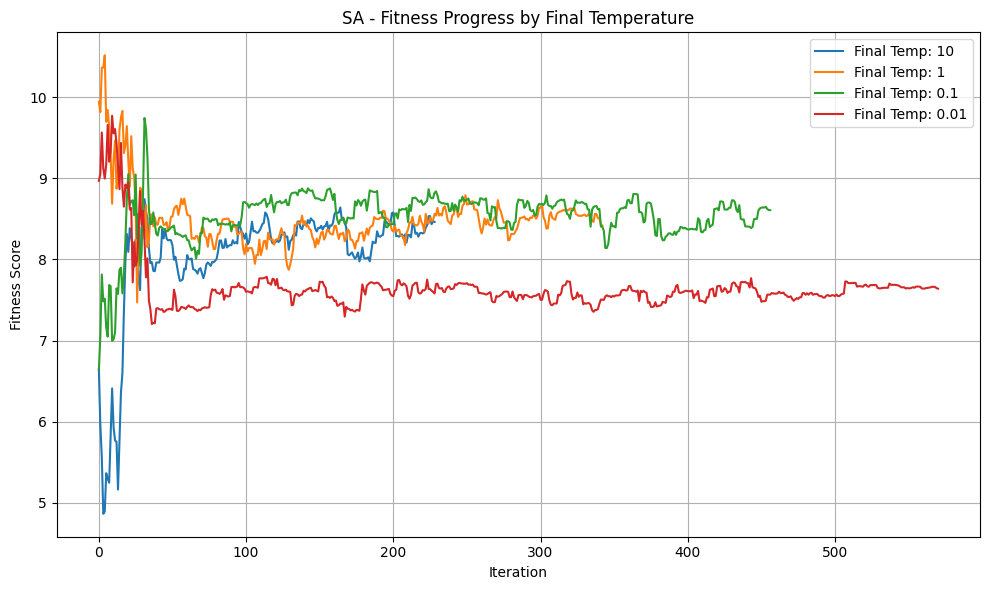

In [126]:
fitness_histories_final_temp = []

for ftemp in final_temps:
    _, _, history = simulated_annealing(
        df=df_input.copy(),
        initial_temp=1000,
        final_temp=ftemp,
        alpha=0.98,
        max_iter=2000,
        num_points=20,
        is_random=True,
        return_history=True
    )
    fitness_histories_final_temp.append((ftemp, history))

# Plot
plt.figure(figsize=(10, 6))
for ftemp, history in fitness_histories_final_temp:
    plt.plot(history, label=f'Final Temp: {ftemp}')
plt.title("SA - Fitness Progress by Final Temperature")
plt.xlabel("Iteration")
plt.ylabel("Fitness Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## SA Direct Experiments

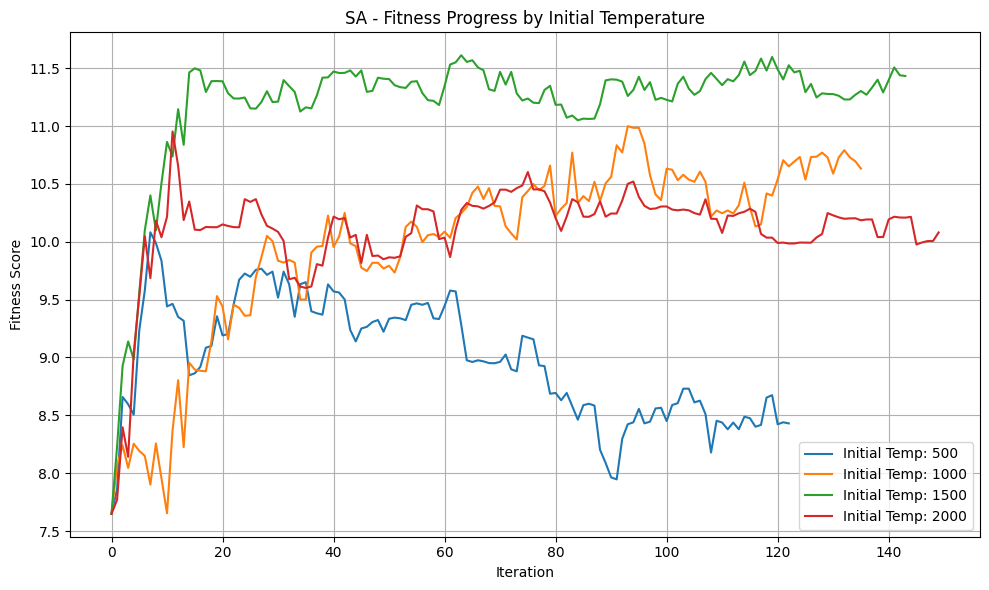

In [140]:
fitness_histories = []

for temp in initial_temps:
    _, _, history = simulated_annealing(
        df=df_input.copy(),
        initial_temp=temp,
        final_temp=1,
        alpha=0.95,
        max_iter=500,
        num_points=20,
        is_random=False,
        return_history=True
    )
    fitness_histories.append((temp, history))

# Plot
plt.figure(figsize=(10, 6))
for temp, history in fitness_histories:
    plt.plot(history, label=f'Initial Temp: {temp}')
plt.title("SA - Fitness Progress by Initial Temperature")
plt.xlabel("Iteration")
plt.ylabel("Fitness Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


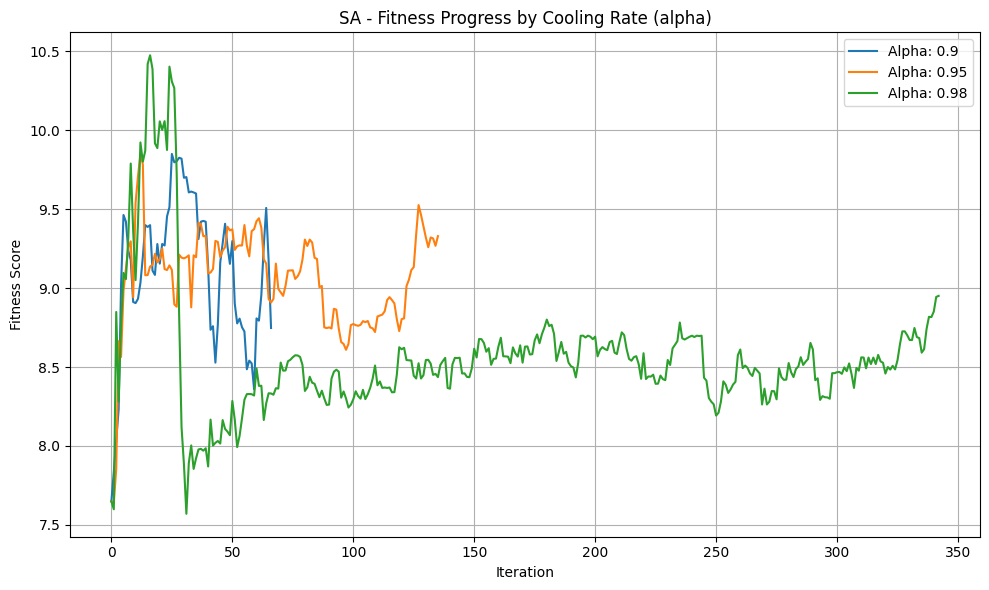

In [143]:
fitness_histories_alpha = []

for alpha in alphas:
    _, _, history = simulated_annealing(
        df=df_input.copy(),
        initial_temp=1000,
        final_temp=1,
        alpha=alpha,
        max_iter=500,
        num_points=20,
        is_random=False,
        return_history=True
    )
    fitness_histories_alpha.append((alpha, history))

# Plot
plt.figure(figsize=(10, 6))
for alpha, history in fitness_histories_alpha:
    plt.plot(history, label=f'Alpha: {alpha}')
plt.title("SA - Fitness Progress by Cooling Rate (alpha)")
plt.xlabel("Iteration")
plt.ylabel("Fitness Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


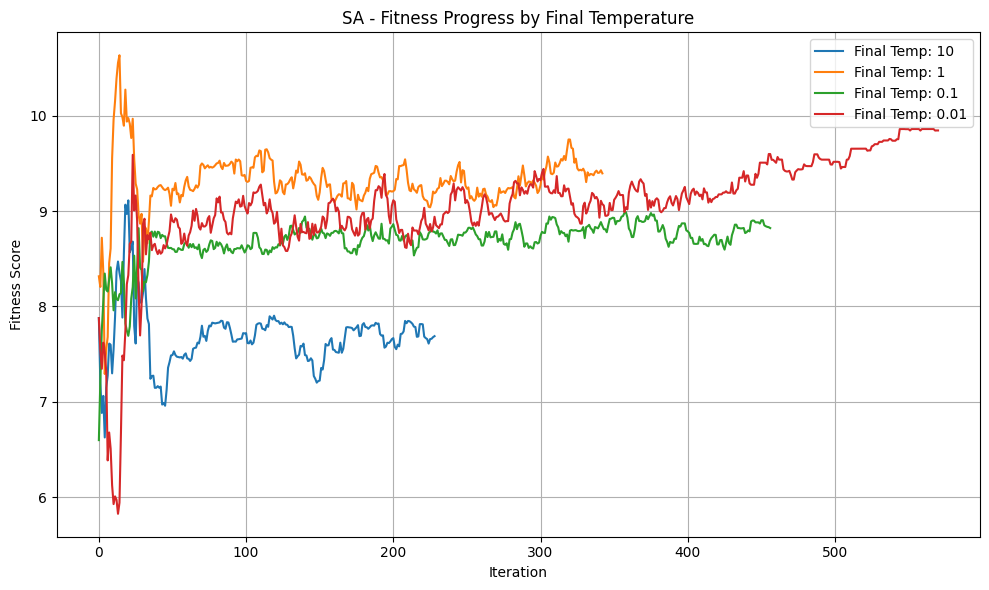

In [144]:
fitness_histories_final_temp = []

for ftemp in final_temps:
    _, _, history = simulated_annealing(
        df=df_input.copy(),
        initial_temp=1000,
        final_temp=ftemp,
        alpha=0.98,
        max_iter=2000,
        num_points=20,
        is_random=True,
        return_history=True
    )
    fitness_histories_final_temp.append((ftemp, history))

# Plot
plt.figure(figsize=(10, 6))
for ftemp, history in fitness_histories_final_temp:
    plt.plot(history, label=f'Final Temp: {ftemp}')
plt.title("SA - Fitness Progress by Final Temperature")
plt.xlabel("Iteration")
plt.ylabel("Fitness Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()